In [1]:
!pip install missingno
!pip install xgboost
!pip install tensorflow
!pip install -q shap
!pip install -q boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import requests
import zipfile
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
import xgboost

In [3]:
import os
import sys

kaggle_json_path = '/content/kaggle(2).json'
kaggle_dir = os.path.expanduser('~/.kaggle')
target_kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')

# Create a .kaggle directory if it doesn't exist
os.makedirs(kaggle_dir, exist_ok=True)

if os.path.exists(kaggle_json_path):
    # Move the uploaded kaggle.json file to the correct directory
    !mv {kaggle_json_path} {target_kaggle_json_path}

    # Set permissions for the kaggle.json file
    !chmod 600 {target_kaggle_json_path}
    print(f"'{kaggle_json_path}' moved to '{target_kaggle_json_path}' and permissions set.")
else:
    print("WARNING: 'kaggle.json' not found in the current working directory.")
    print("Please upload your kaggle.json file to the Colab environment using the 'Files' tab (folder icon on the left sidebar).")
    print("After uploading, please re-run this cell and the subsequent cells for Kaggle dataset download.")
    # The 'kaggle' library authentication will fail in the next cell if kaggle.json is not present.
    # We let the pip install run as it's independent.




Please upload your kaggle.json file to the Colab environment using the 'Files' tab (folder icon on the left sidebar).
After uploading, please re-run this cell and the subsequent cells for Kaggle dataset download.


In [4]:
import zipfile

# Dataset name from the URL: chethuhn/network-intrusion-dataset
dataset_name = "chethuhn/network-intrusion-dataset"

# Download the dataset from Kaggle
# First, ensure Kaggle library is properly configured and authenticated.
!kaggle datasets download -d {dataset_name}

# Define the directory where the dataset will be extracted
extract_dir = "network-intrusion-dataset"
os.makedirs(extract_dir, exist_ok=True)

# Unzip the dataset. The downloaded file will be named 'network-intrusion-dataset.zip'
zip_file_path = f"{dataset_name.split('/')[-1]}.zip"

# Check if the zip file exists before trying to open it
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print(f"Dataset extracted to '{extract_dir}/")
    # Remove the zip file after extraction to save space
    os.remove(zip_file_path)
else:
    print(f"Error: Zip file '{zip_file_path}' not found. Please ensure it's uploaded or downloaded.")

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
100% 230M/230M [00:01<00:00, 129MB/s] 

Dataset extracted to 'network-intrusion-dataset/


In [5]:
input_dir = "network-intrusion-dataset"
output_csv = "merged_network_intrusion_dataset.csv"

csv_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

In [6]:
first_chunk = True

for file in csv_files:
    file_path = os.path.join(input_dir, file)
    for chunk in pd.read_csv(file_path, chunksize=100_000, low_memory=False):
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.dropna(inplace=True)
        chunk.to_csv(
            output_csv,
            mode="w" if first_chunk else "a",
            index=False,
            header=first_chunk
        )
        first_chunk = False

In [7]:
data = pd.read_csv(output_csv)

In [8]:
print(data.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [9]:
duplicates = data[data.duplicated()]
print("No of duplicates:",len(duplicates))
print("After removing duplicates")
data.drop_duplicates(inplace = True)
data.shape

No of duplicates: 307078
After removing duplicates


(2520798, 79)

In [10]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

categorical_cols = data.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if not data[col].mode().empty:
        data[col] = data[col].fillna(data[col].mode()[0])

print(data.isna().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64


In [11]:
types = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'PortScan': 'Port Scan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack � Brute Force': 'Web Attack',
    'Web Attack � XSS': 'Web Attack',
    'Web Attack � Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed'
}
data['types'] = data[' Label'].map(types)

In [12]:
selected_types = ['BENIGN', 'DoS', 'DDoS']
data = data[data['types'].isin(selected_types)].copy()

print("Class distribution after filtering:")
print(data['types'].value_counts())

Class distribution after filtering:
types
BENIGN    2095057
DoS        193745
DDoS       128014
Name: count, dtype: int64


In [13]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

categorical_cols = data.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if not data[col].mode().empty:
        data[col] = data[col].fillna(data[col].mode()[0])

print(data.isna().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
types                          0
Length: 80, dtype: int64


In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['target'] = le.fit_transform(data['types'])
encoded = data['target'].unique()
print(encoded)
for val in encoded:
    print(val,le.inverse_transform([val])[0])

[0 2 1]
0 BENIGN
2 DoS
1 DDoS


In [15]:
num_unique = data.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index
dropped_cols = one_variable.index
data = data[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index([' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk',
       ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [16]:
cols_to_drop = [' Label', 'types']
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors='ignore')

In [17]:
data['target'].value_counts()

,count
target,
0,2095057
2,193745
1,128014


In [18]:
class_counts = data['target'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = data[data['target'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['target'] == name]
  df = df.sample(n = 9000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)
df['target'].value_counts()
newdata = df.copy()

In [19]:
class_counts = data['target'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = data[data['target'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['target'] == name]
  df = df.sample(n = 800, random_state = 0)

  dfs.append(df)

df1 = pd.concat(dfs, ignore_index = True)
df1['target'].value_counts()
newdat = df1.copy()

In [20]:
newdat

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
0,53,193,2,2,96,180,48,48,48.000000,0.000000,...,32,0.000000e+00,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,0
1,57330,76270435,5,9,12976,56,8760,0,2595.200000,3639.717393,...,20,1.957400e+04,0.000000,19574,19574,3.810000e+07,4.020000e+07,66600000,9661722,0
2,443,116961935,21,19,1770,5095,1135,0,84.285714,265.975402,...,32,1.340103e+05,336797.502242,1203486,36651,9.612817e+06,1.378048e+06,10015243,5236939,0
3,53,30706,1,1,50,66,50,50,50.000000,0.000000,...,20,0.000000e+00,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,0
4,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.000000e+00,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,80,69101,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.000000e+00,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,1
2396,80,85856250,8,4,56,11601,20,0,7.000000,5.656854,...,20,4.432901e+06,0.000000,4432901,4432901,8.030000e+07,0.000000e+00,80300000,80300000,1
2397,80,3189346,5,0,30,0,6,6,6.000000,0.000000,...,20,0.000000e+00,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,1
2398,80,26901,3,4,26,11601,20,0,8.666667,10.263203,...,20,0.000000e+00,0.000000,0,0,0.000000e+00,0.000000e+00,0,0,1


In [21]:
newdat.to_csv('newdat2.csv', index=False)


In [22]:
from sklearn.preprocessing import StandardScaler

features = newdata.drop('target', axis = 1)
attacks = newdata['target']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [23]:
from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

information retained: 99.65%


In [24]:
transformed_features = ipca.transform(scaled_features)
newdata = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
newdata['target'] = attacks.values

In [25]:
normal_traffic = newdata.loc[newdata['target'] == 0]
intrusions = newdata.loc[newdata['target'] != 0]

# To balance the dataset for binary classification (normal vs. intrusion),
# undersample the 'intrusions' class to match the size of the 'normal_traffic' class.
# This ensures an equal number of samples for both categories without replacement.
intrusions_sampled = intrusions.sample(n=len(normal_traffic), replace=False, random_state=42)

ids_data = pd.concat([intrusions_sampled, normal_traffic])
# Convert original target labels (0, 1, 2) to binary (0 for normal, 1 for intrusion)
ids_data['target'] = np.where((ids_data['target'] == 0), 0, 1)
bc_data = ids_data.sample(n = 15000, random_state=42)

print(bc_data['target'].value_counts())

target
1    7538
0    7462
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split

X_bc = bc_data.drop('target', axis = 1)
y_bc = bc_data['target']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size = 0.25, random_state = 0)

In [27]:
from sklearn.model_selection import train_test_split

# Assuming ' Label' is the target variable (corrected column name)
X = newdata.drop('target', axis=1)
y = newdata['target']

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (21600, 35)
Shape of X_test: (5400, 35)
Shape of y_train: (21600,)
Shape of y_test: (5400,)


In [28]:
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Training and testing datasets saved as X_train.csv, y_train.csv, X_test.csv, and y_test.csv")

Training and testing datasets saved as X_train.csv, y_train.csv, X_test.csv, and y_test.csv


In [29]:
import numpy as np
import pandas as pd

def add_noise(X, noise_level=0.01):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

def scale_features(X, low=0.95, high=1.05):
    scale = np.random.uniform(low, high, X.shape)
    return X * scale

def augment_test_data(X, y):
    X_noise = add_noise(X)
    X_scaled = scale_features(X)

    # Combine original + augmented
    X_aug = pd.concat([X, pd.DataFrame(X_noise, columns=X.columns),
                          pd.DataFrame(X_scaled, columns=X.columns)], ignore_index=True)

    y_aug = pd.concat([y, y, y], ignore_index=True)

    return X_aug, y_aug


X_test_aug, y_test_aug = augment_test_data(X_test, y_test)

print("Original Test Shape:", X_test.shape)
print("Augmented Test Shape:", X_test_aug.shape)

Original Test Shape: (5400, 35)
Augmented Test Shape: (16200, 35)


In [30]:
y_test_aug

,target
0,0
1,1
2,0
3,2
4,2
...,...
16195,0
16196,2
16197,0
16198,0


In [31]:
y_test

,target
5312,0
18357,1
6428,0
15414,2
10610,2
...,...
5195,0
9888,2
2273,0
3699,0


In [32]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 15, max_depth = 8, max_features = 20, random_state = 0)
rf.fit(X_train, y_train)

cv_rf = cross_val_score(rf, X_train, y_train, cv = 5)
print('Random Forest Model')
y_pred_rf = rf.predict(X_test_aug)
y_prob_rf = rf.predict_proba(X_test_aug)

acc_rf = accuracy_score(y_test_aug, y_pred_rf)
prec_rf = precision_score(y_test_aug, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test_aug, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test_aug, y_pred_rf, average='weighted')
auc_rf = roc_auc_score(
    y_test_aug,
    y_prob_rf,
    multi_class='ovr',
    average='weighted'
)

print("Random Forest on Augmented Test Data")
print(f"Accuracy: {acc_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print("Random Forest Model")
print(f"CV scores: {cv_rf}")
print(f"Mean CV: {cv_rf.mean():.4f}")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision (weighted): {prec_rf:.4f}")
print(f"Recall (weighted): {rec_rf:.4f}")
print(f"F1 (weighted): {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_aug, y_pred_rf,digits=6))

cm_rf = confusion_matrix(y_test_aug, y_pred_rf)
print("Confusion Matrix:")
print(cm_rf)

Random Forest Model
Random Forest on Augmented Test Data
Accuracy: 0.9813
F1 Score: 0.9813
Random Forest Model
CV scores: [0.99375    0.99328704 0.99074074 0.99351852 0.99189815]
Mean CV: 0.9926
Accuracy: 0.9813
Precision (weighted): 0.9815
Recall (weighted): 0.9813
F1 (weighted): 0.9813

Classification Report:
              precision    recall  f1-score   support

           0   0.973493  0.991311  0.982321      5409
           1   0.998468  0.972766  0.985450      5361
           2   0.972756  0.979742  0.976236      5430

    accuracy                       0.981296     16200
   macro avg   0.981572  0.981273  0.981336     16200
weighted avg   0.981511  0.981296  0.981317     16200

Confusion Matrix:
[[5362    4   43]
 [  40 5215  106]
 [ 106    4 5320]]


In [33]:
from sklearn.linear_model import LogisticRegression

lr1 = LogisticRegression(max_iter = 10000, C = 0.1, random_state = 0, solver = 'saga')
lr1.fit(X_train, y_train)
cv_lr1 = cross_val_score(lr1, X_train, y_train, cv = 5)

y_pred_lr1 = lr1.predict(X_test_aug)
y_prob_lr1 = lr1.predict_proba(X_test_aug)

acc_lr1 = accuracy_score(y_test_aug, y_pred_lr1)
prec_lr1 = precision_score(y_test_aug, y_pred_lr1, average='weighted')
rec_lr1 = recall_score(y_test_aug, y_pred_lr1, average='weighted')
f1_lr1 = f1_score(y_test_aug, y_pred_lr1, average='weighted')

print('Logistic Regression on Augmented Test Data')
print(f'Accuracy: {acc_lr1:.4f}')
print('Logistic regression Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lr1)))
print(f'\nMean cross-validation score: {cv_lr1.mean()}')
print(f'\n Accuracy of this model:{acc_lr1}')

Logistic Regression on Augmented Test Data
Accuracy: 0.9637
Logistic regression Model 1

Cross-validation scores: 0.9652777777777778, 0.9576388888888889, 0.9597222222222223, 0.9671296296296297, 0.9606481481481481

Mean cross-validation score: 0.9620833333333334

 Accuracy of this model:0.9637037037037037


In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth = 8)
dt.fit(X_train, y_train)

cv_dt = cross_val_score(dt, X_train, y_train, cv = 5)
y_pred_dt = dt.predict(X_test_aug)
y_prob_dt = dt.predict_proba(X_test_aug)

acc_dt = accuracy_score(y_test_aug, y_pred_dt)
prec_dt = precision_score(y_test_aug, y_pred_dt,average='weighted')
rec_dt = recall_score(y_test_aug, y_pred_dt,average='weighted')
f1_dt = f1_score(y_test_aug, y_pred_dt,average ='weighted')
auc_dt = roc_auc_score(y_test_aug, y_prob_dt,multi_class='ovr',average='weighted')
print('Decision Tree Model')
print(f'Cross-validation scores: {cv_dt}')
print(f'Mean cross-validation score: {cv_dt.mean():.4f}')
print(f'Accuracy: {acc_dt:.4f}, Precision: {prec_dt:.4f}, Recall: {rec_dt:.4f}, F1: {f1_dt:.4f}, AUC: {auc_dt:.4f}')
print(classification_report(y_test_aug, y_pred_dt,digits=6))
cm_dt = confusion_matrix(y_test_aug, y_pred_dt)
print(cm_dt)

Decision Tree Model
Cross-validation scores: [0.98981481 0.9837963  0.98611111 0.98842593 0.98587963]
Mean cross-validation score: 0.9868
Accuracy: 0.9578, Precision: 0.9589, Recall: 0.9578, F1: 0.9579, AUC: 0.9744
              precision    recall  f1-score   support

           0   0.942428  0.974487  0.958189      5409
           1   0.995445  0.937512  0.965610      5361
           2   0.939187  0.961326  0.950127      5430

    accuracy                       0.957840     16200
   macro avg   0.959020  0.957775  0.957976     16200
weighted avg   0.958886  0.957840  0.957943     16200

[[5271   12  126]
 [ 123 5026  212]
 [ 199   11 5220]]


In [35]:
# Cell for XGBoost
from xgboost import XGBClassifier

num_classes = len(np.unique(y_train))

xgb = XGBClassifier(n_estimators=100, random_state=0,num_class=num_classes, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5)
y_pred_xgb = xgb.predict(X_test_aug)
y_prob_xgb = xgb.predict_proba(X_test_aug)

acc_xgb = accuracy_score(y_test_aug, y_pred_xgb)
prec_xgb = precision_score(y_test_aug, y_pred_xgb, average='weighted')
rec_xgb = recall_score(y_test_aug, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test_aug, y_pred_xgb, average='weighted')
auc_xgb = roc_auc_score(y_test_aug, y_prob_xgb,multi_class='ovr',average='weighted')


print('XGBoost')
print(f'Cross-validation scores: {cv_xgb}')
print(f'Mean cross-validation score: {cv_xgb.mean():.4f}')
print(f'Accuracy: {acc_xgb:.4f},\n Precision: {prec_xgb:.4f}, \nRecall: {rec_xgb:.4f}, \nF1: {f1_xgb:.4f}, \nAUC: {auc_xgb:.8f}')
cm_xgb = confusion_matrix(y_test_aug, y_pred_xgb)
print(cm_xgb)

XGBoost
Cross-validation scores: [0.99814815 0.99699074 0.99699074 0.99722222 0.9974537 ]
Mean cross-validation score: 0.9974
Accuracy: 0.9943,
 Precision: 0.9944, 
Recall: 0.9943, 
F1: 0.9943, 
AUC: 0.99990512
[[5388    0   21]
 [  16 5345    0]
 [  54    1 5375]]


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization

X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test_aug.values.reshape(X_test_aug.shape[0], X_test_aug.shape[1], 1)

y_train_cat = y_train
y_test_cat = y_test_aug

num_classes = len(np.unique(y_train))

cnn_model = Sequential([
    # Block 1
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Block 2
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Flatten and Dense layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),

    # Output layer
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history = cnn_model.fit(X_train_cnn, y_train_cat,epochs=500,batch_size=32,validation_split=0.2,callbacks=[early_stop],verbose=0)

y_prob_cnn = cnn_model.predict(X_test_aug)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


507/507 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step


In [37]:
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)
acc_cnn = accuracy_score(y_test_aug, y_pred_cnn)
prec_cnn = precision_score(y_test_aug, y_pred_cnn,average='weighted')
rec_cnn = recall_score(y_test_aug, y_pred_cnn,average='weighted')
f1_cnn = f1_score(y_test_aug, y_pred_cnn,average='weighted')
auc_cnn = roc_auc_score(y_test_aug, y_prob_cnn,multi_class='ovr',average='weighted')

print('CNN')
print(f'Accuracy: {acc_cnn:.4f}, Precision: {prec_cnn:.4f}, Recall: {rec_cnn:.4f}, F1: {f1_cnn:.4f}, AUC: {auc_cnn:.4f}')
print(classification_report(y_test_aug, y_pred_cnn, digits=5))

cm_cnn = confusion_matrix(y_test_aug, y_pred_cnn)
print(cm_cnn)

CNN
Accuracy: 0.9929, Precision: 0.9929, Recall: 0.9929, F1: 0.9929, AUC: 0.9998
              precision    recall  f1-score   support

           0    0.99256   0.98613   0.98934      5409
           1    0.99925   0.99851   0.99888      5361
           2    0.98702   0.99411   0.99055      5430

    accuracy                        0.99290     16200
   macro avg    0.99294   0.99292   0.99292     16200
weighted avg    0.99292   0.99290   0.99290     16200

[[5334    4   71]
 [   8 5353    0]
 [  32    0 5398]]


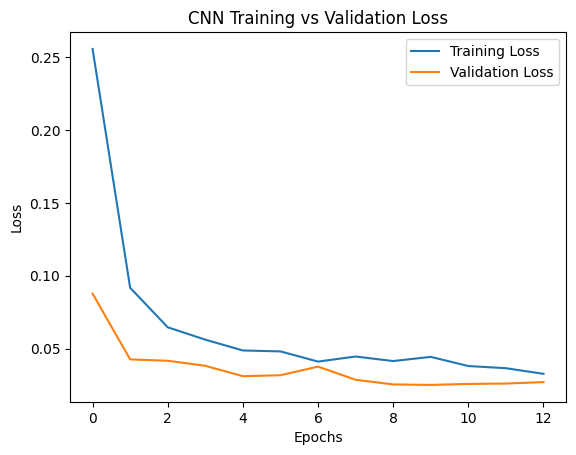

In [38]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.show()

In [39]:
le = LabelEncoder()

# Fit ONLY on training labels
y_train_enc = le.fit_transform(y_train)

# Transform test labels using same mapping
y_test_enc = le.transform(y_test)

In [40]:
num_classes = len(np.unique(y_train_enc))
num_classes

3

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

num_classes = len(np.unique(y_train_enc))

bilstm_model = Sequential([
    Bidirectional(LSTM(50, return_sequences=True),
                  input_shape=(X_train_cnn.shape[1], 1)),
    Dropout(0.5),
    Bidirectional(LSTM(50)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history =  bilstm_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
y_prob_bilstm = bilstm_model.predict(X_test_cnn)
y_pred_bilstm = np.argmax(y_prob_bilstm, axis=1)

acc_bilstm  = accuracy_score(y_test_aug, y_pred_bilstm)
prec_bilstm = precision_score(y_test_aug, y_pred_bilstm, average='weighted')
rec_bilstm  = recall_score(y_test_aug, y_pred_bilstm, average='weighted')
f1_bilstm   = f1_score(y_test_aug, y_pred_bilstm, average='weighted')
auc_bilstm  = roc_auc_score(y_test_aug,y_prob_bilstm,multi_class='ovr',average='weighted')
print('BiLSTM')
print(f'Accuracy: {acc_bilstm:.4f}, Precision: {prec_bilstm:.4f}, Recall: {rec_bilstm:.4f}, F1: {f1_bilstm:.4f}, AUC: {auc_bilstm:.4f}')
print(classification_report(y_test_aug, y_pred_bilstm,digits=5))
cm_bilstm = confusion_matrix(y_test_aug, y_pred_bilstm)
print(cm_bilstm)

507/507 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step
BiLSTM
Accuracy: 0.9827, Precision: 0.9829, Recall: 0.9827, F1: 0.9827, AUC: 0.9991
              precision    recall  f1-score   support

           0    0.98899   0.96284   0.97574      5409
           1    0.99590   0.99758   0.99674      5361
           2    0.96405   0.98785   0.97580      5430

    accuracy                        0.98272     16200
   macro avg    0.98298   0.98275   0.98276     16200
weighted avg    0.98292   0.98272   0.98271     16200

[[5208    6  195]
 [   8 5348    5]
 [  50   16 5364]]


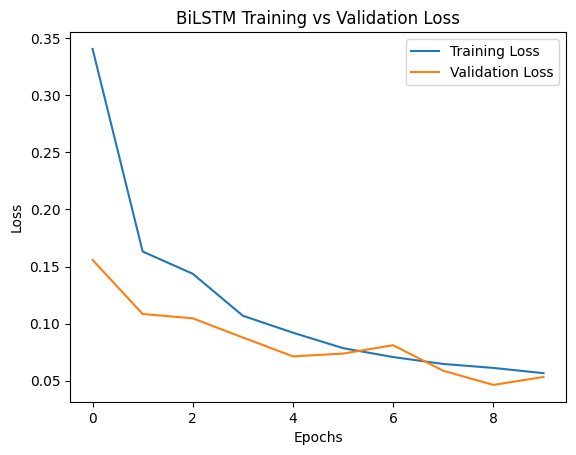

In [81]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BiLSTM Training vs Validation Loss')
plt.legend()
plt.show()


📊 MODEL COMPARISON TABLE:
    Model  Accuracy  Precision    Recall        F1       AUC  \
0      RF  0.981296   0.981511  0.981296  0.981317  0.999563   
1     XGB  0.994321   0.994351  0.994321  0.994326  0.999905   
2     CNN  0.992901   0.992916  0.992901  0.992901  0.999756   
3  BiLSTM  0.982716   0.982918  0.982716  0.982710  0.999071   

   False Positive Rate (FPR)%  False Negative Rate (FNR)%  
0                    0.936753                    1.872692  
1                    0.284300                    0.566528  
2                    0.355607                    0.708374  
3                    0.865822                    1.724664  

 Best Model based on F1-score: XGB


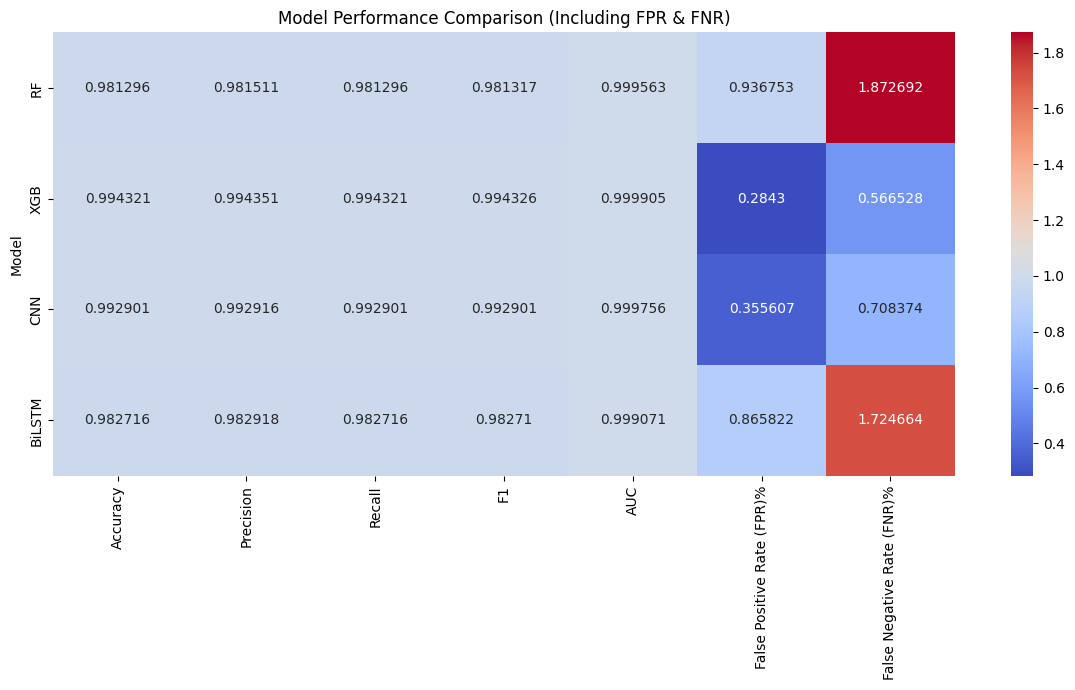

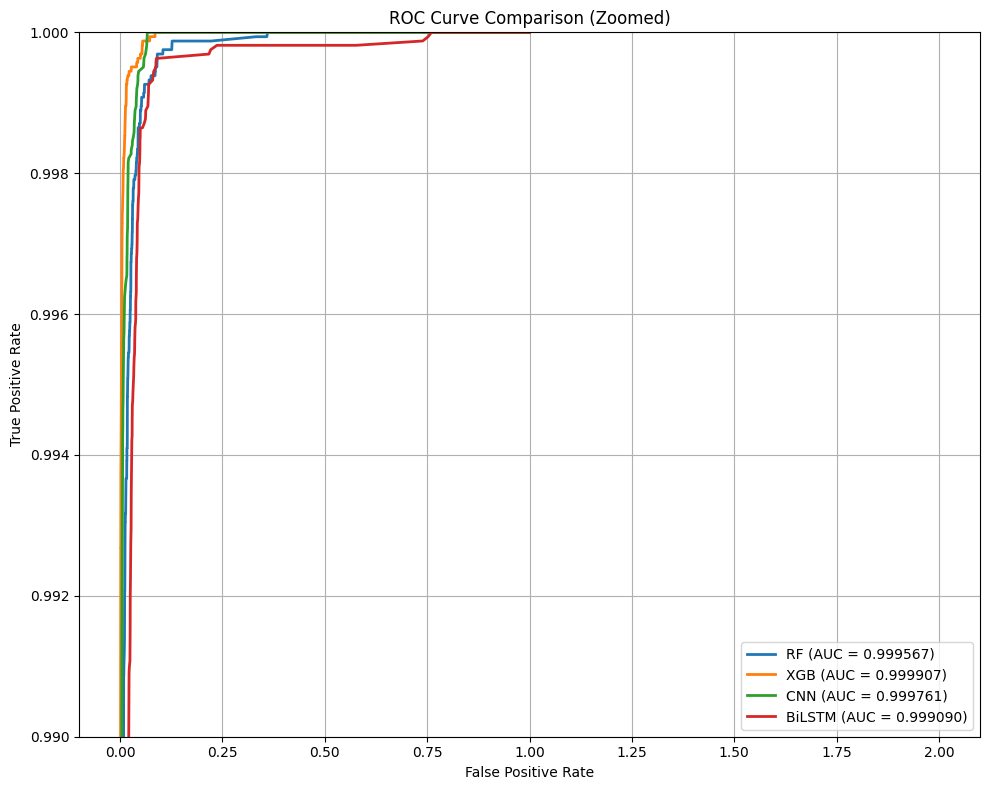

In [44]:
# ===================== IMPORTS =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize


# ===================== FP & FN RATE FUNCTION =====================
def compute_fpr_fnr(y_true, y_pred):
    """
    Computes macro-averaged False Positive Rate and False Negative Rate
    (suitable for multiclass problems)
    """
    cm = confusion_matrix(y_true, y_pred)

    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    FPR = FP / (FP + TN)
    FNR = FN / (FN + TP)

    return np.mean(FPR)*100, np.mean(FNR)*100


# ===================== FP & FN FOR EACH MODEL =====================
fpr_rf, fnr_rf = compute_fpr_fnr(y_test_aug, y_pred_rf)
fpr_xgb, fnr_xgb = compute_fpr_fnr(y_test_aug, y_pred_xgb)
fpr_cnn, fnr_cnn = compute_fpr_fnr(y_test_aug, y_pred_cnn)
fpr_bilstm, fnr_bilstm = compute_fpr_fnr(y_test_aug, y_pred_bilstm)


# ===================== COMPARISON TABLE =====================
models_summary = pd.DataFrame({
    'Model': ['RF', 'XGB', 'CNN', 'BiLSTM'],
    'Accuracy': [acc_rf, acc_xgb, acc_cnn, acc_bilstm],
    'Precision': [prec_rf, prec_xgb, prec_cnn, prec_bilstm],
    'Recall': [rec_rf, rec_xgb, rec_cnn, rec_bilstm],
    'F1': [f1_rf, f1_xgb, f1_cnn, f1_bilstm],
    'AUC': [auc_rf, auc_xgb, auc_cnn, auc_bilstm],
    'False Positive Rate (FPR)%': [fpr_rf, fpr_xgb, fpr_cnn, fpr_bilstm],
    'False Negative Rate (FNR)%': [fnr_rf, fnr_xgb, fnr_cnn, fnr_bilstm]
})

print("\n📊 MODEL COMPARISON TABLE:")
print(models_summary.round(6))


# ===================== BEST MODEL =====================
best_idx = models_summary['F1'].idxmax()
best_model_name = models_summary.loc[best_idx, 'Model']
print(f"\n Best Model based on F1-score: {best_model_name}")


# ===================== HEATMAP =====================
plt.figure(figsize=(12, 7))
sns.heatmap(
    models_summary.set_index('Model'),
    annot=models_summary.set_index('Model').round(6),
    fmt='',
    cmap='coolwarm'
)
plt.title('Model Performance Comparison (Including FPR & FNR)')
plt.tight_layout()
plt.savefig('model_comparison_heatmap_extended.png', dpi=300)
plt.show()


# ===================== ROC CURVE (ZOOMED) =====================
n_classes = len(np.unique(y_test_aug)) # Use y_test_aug to get the correct number of samples
y_test_bin = label_binarize(y_test_aug, classes=range(n_classes))

model_probs = {
    'RF': y_prob_rf,
    'XGB': y_prob_xgb,
    'CNN': y_prob_cnn,
    'BiLSTM': y_prob_bilstm
}

plt.figure(figsize=(10, 8))

for model_name, y_prob in model_probs.items():
    fpr = {}
    tpr = {}

    for i in range(n_classes):
        # Ensure y_test_bin and y_prob have consistent number of samples
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {macro_auc:.6f})'
    )

plt.xlim(-0.10, 2.1)
plt.ylim(0.99, 1.0)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Zoomed)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_comparison_zoomed.png', dpi=300)
plt.show()

In [45]:
class_counts = data['target'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = data[data['target'].isin(class_names)]

dfs1 = []
for name in class_names:
  df1 = selected[selected['target'] == name]
  if len(df1) > 2500:
    df1 = df1.sample(n = 9000, random_state = 0)

  dfs1.append(df1)

df1 = pd.concat(dfs1, ignore_index = True)
df1['target'].value_counts()
newdataxai = df.copy()
newdataxai['target'] = df1['target']
newdataxai

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
2626522,80,4825910,5,0,30,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,NaN
2640167,80,70892859,8,5,56,11601,20,0,7.000000,5.656854,...,20,3162901.0,0.0,3162901,3162901,67700000.0,0.0,67700000,67700000,NaN
2637524,80,700511,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,NaN
2764263,80,11815663,4,0,24,0,6,6,6.000000,0.000000,...,20,1978.0,0.0,1978,1978,11800000.0,0.0,11800000,11800000,NaN
2665166,80,2095976,5,0,30,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2737621,80,69101,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,NaN
2716944,80,85856250,8,4,56,11601,20,0,7.000000,5.656854,...,20,4432901.0,0.0,4432901,4432901,80300000.0,0.0,80300000,80300000,NaN
2715852,80,3189346,5,0,30,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,NaN
2678748,80,26901,3,4,26,11601,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,NaN


In [46]:
features = newdataxai.drop('target', axis = 1)
labels = newdataxai['target']

X_train1, X_test1, y_train1, y_test1 = train_test_split(features, labels, test_size = 0.2, random_state = 0)

In [47]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, List, Tuple, Union, Optional

try:
    import dice_ml
    DICE_AVAILABLE = True
except ImportError:
    DICE_AVAILABLE = False

def get_class_names(y) -> List[str]:
    """
    You should customize this mapping according to your actual labels
    """
    mapping = {
        0: "BENIGN",
        1: "DDoS",
        2: "DoS",
    }
    unique = np.unique(y)
    return [mapping.get(int(v), f"Class {int(v)}") for v in unique]


def prediction_to_label(pred_proba: np.ndarray, class_names: List[str]) -> Dict:
    idx = pred_proba.argmax()
    return {
        "predicted_class": class_names[idx],
        "confidence": float(pred_proba.max()),
        "probabilities": dict(zip(class_names, pred_proba.round(4)))
    }

In [48]:
def compute_global_shap(
    model,
    X_background: pd.DataFrame,
    X_summary: Optional[pd.DataFrame] = None,
    max_samples: int = 300,
    tree_limit: Optional[int] = None
) -> shap.Explainer:
    """
    Best practice for XGBoost / LightGBM / CatBoost / sklearn trees:
    → TreeExplainer is fast and exact
    """
    try:
        explainer = shap.TreeExplainer(
            model,
            feature_perturbation="tree_path_dependent",
            model_output="raw"
        )
        print("✅ Using fast & accurate TreeExplainer")
    except Exception as e:
        print("TreeExplainer not available → falling back to KernelExplainer", e)
        if X_summary is None:
            X_summary = shap.kmeans(X_background.values, k=min(50, len(X_background))).data
        explainer = shap.KernelExplainer(
            lambda x: model.predict_proba(x) if hasattr(model, "predict_proba") else model.predict(x),
            X_summary,
            link="logit"
        )

    if tree_limit is not None and hasattr(explainer, "model"):
        if hasattr(explainer.model, "limit_trees"):
            explainer.model = explainer.model.limit_trees(tree_limit)

    return explainer

In [49]:
def plot_global_shap_summary(
    shap_values: Union[shap.Explanation, np.ndarray, list],
    features: pd.DataFrame,
    class_names: List[str] = None,
    max_display: int = 15,
    plot_type: str = "bar"          # "bar" / "dot" / "violin"
):
    plt.figure(figsize=(12, max_display//1.8 + 3))

    if isinstance(shap_values, list) or (hasattr(shap_values, 'values') and len(shap_values.values.shape) == 3):
        # Multi-class case - make sure class_names are passed correctly
        shap.summary_plot(
            shap_values,
            features,
            class_names=class_names,        # ← This is the key line
            plot_type=plot_type,
            max_display=max_display,
            show=False
        )
    else:
        # Binary or single output case
        shap.summary_plot(
            shap_values,
            features,
            plot_type=plot_type,
            max_display=max_display,
            show=False
        )

    plt.title("Global SHAP Feature Importance")
    plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
    plt.tight_layout()
    plt.show()

def global_feature_importance_table(
    shap_values: np.ndarray,
    feature_names: List[str],
    top_n: int = 20
) -> pd.DataFrame:

    if shap_values.ndim == 3: # Multi-class: (samples, features, classes)
        # Average absolute SHAP values across samples and classes
        importance = np.mean(np.abs(shap_values), axis=(0, 2))
    elif shap_values.ndim == 2: # Single output: (samples, features)
        # Average absolute SHAP values across samples
        importance = np.abs(shap_values).mean(axis=0)
    else:
        raise ValueError("Unsupported SHAP values dimension for importance calculation.")

    df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": importance.round(4)
    }).sort_values("mean_abs_shap", ascending=False).head(top_n)

    df["rank"] = range(1, len(df)+1)
    df["importance_pct"] = (df["mean_abs_shap"] / df["mean_abs_shap"].sum() * 100).round(2)

    return df

In [50]:
def explain_single_prediction(
    model,
    explainer: shap.Explainer,
    x_instance: Union[pd.Series, pd.DataFrame, np.ndarray],
    class_names: List[str],
    true_label: Optional[int] = None,
    figsize=(14, 7)
) -> Dict:
    # Normalize input
    if isinstance(x_instance, pd.Series):
        x_instance = x_instance.to_frame().T
    elif isinstance(x_instance, np.ndarray):
        x_instance = pd.DataFrame(x_instance, columns=explainer.feature_names)

    # Predict
    proba = model.predict_proba(x_instance)[0]
    pred_idx = proba.argmax()
    pred_label = class_names[pred_idx]

    # SHAP
    shap_values = explainer(x_instance)

    # Creating a single Explanation object for the predicted class
    shap_values_for_predicted_class = shap.Explanation(
        values=shap_values.values[0, :, pred_idx],  # SHAP values for the predicted class
        base_values=explainer.expected_value[pred_idx], # Base value for the predicted class, correctly indexed from explainer
        data=shap_values.data[0], # Data for the instance
        feature_names=shap_values.feature_names # Feature names
    )

    shap.plots.waterfall(shap_values_for_predicted_class, max_display=12, show=False)
    plt.title(f"Waterfall – Predicted: {pred_label} ({proba.max():.1%})")
    plt.tight_layout()
    plt.show()

    shap.plots.force(shap_values_for_predicted_class, matplotlib=True, show=False)
    plt.title(f"Force Plot – {pred_label}")
    plt.show()

    contributions = shap_values.values[0, :, pred_idx]
    features = x_instance.columns
    values = x_instance.iloc[0]

    pos = [(f, c, v) for f, c, v in zip(features, contributions, values) if c > 0.01]
    neg = [(f, c, v) for f, c, v in zip(features, contributions, values) if c < -0.01]

    pos.sort(key=lambda x: x[1], reverse=True)
    neg.sort(key=lambda x: x[1])

    explanation = {
        "predicted_class": pred_label,
        "confidence": float(proba.max()),
        "true_label": class_names[true_label] if true_label is not None else None,
        "top_positive": [(f"{f} = {v:.3g}", f"+{c:.3f}") for f,c,v in pos[:6]],
        "top_negative": [(f"{f} = {v:.3g}", f"{c:.3f}") for f,c,v in neg[:6]],
    }

    print(f"\nPrediction: {pred_label}  ({proba.max():.1%})")
    if explanation["true_label"]:
        print(f"True label : {explanation['true_label']}\n")

    print("Features that increased attack probability:")
    for feat, contrib in explanation["top_positive"][:5]:
        print(f"  \u2022 {feat:>35}  \u2192  {contrib}")

    print("\nFeatures that decreased attack probability:")
    for feat, contrib in explanation["top_negative"][:5]:
        print(f"  \u2022 {feat:>35}  \u2192  {contrib}")

    return explanation

✅ Using fast & accurate TreeExplainer


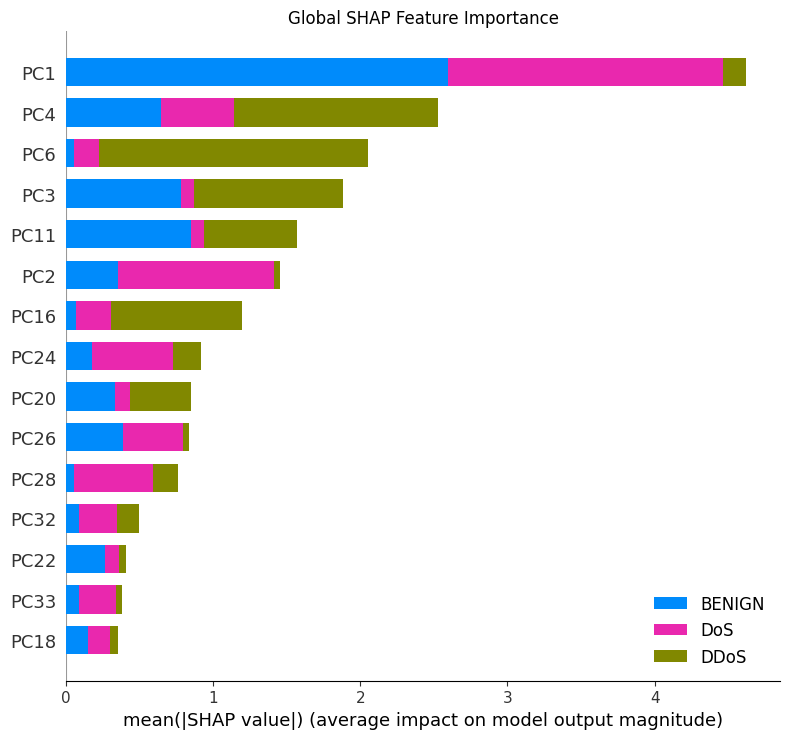

,feature,mean_abs_shap,rank,importance_pct
0,PC1,1.5405,1,22.76
3,PC4,0.8432,2,12.46
5,PC6,0.6838,3,10.10
2,PC3,0.6283,4,9.28
10,PC11,0.5242,5,7.75
1,PC2,0.4840,6,7.15
15,PC16,0.3992,7,5.90
23,PC24,0.3054,8,4.51
19,PC20,0.2832,9,4.18
25,PC26,0.2780,10,4.11


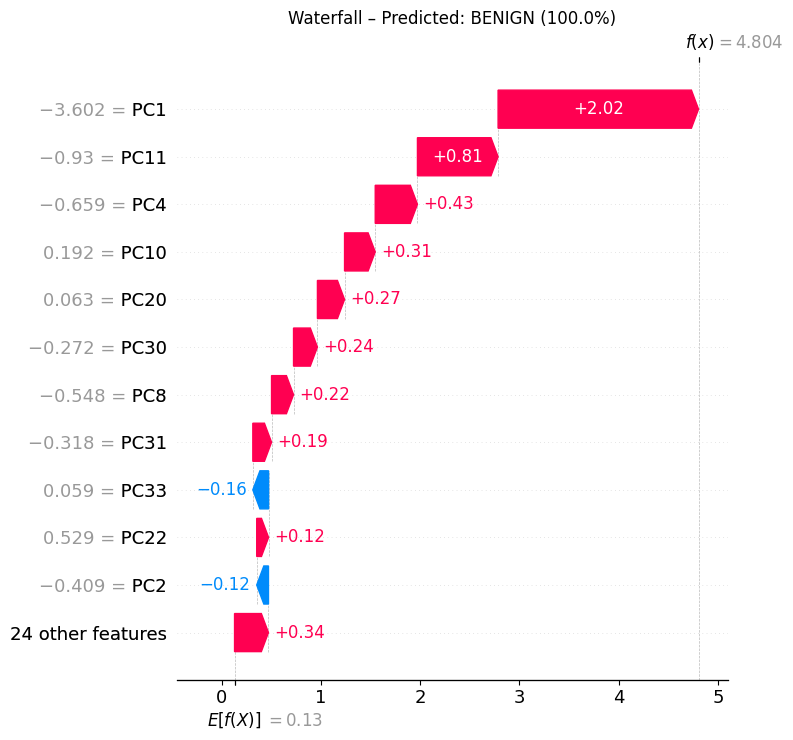

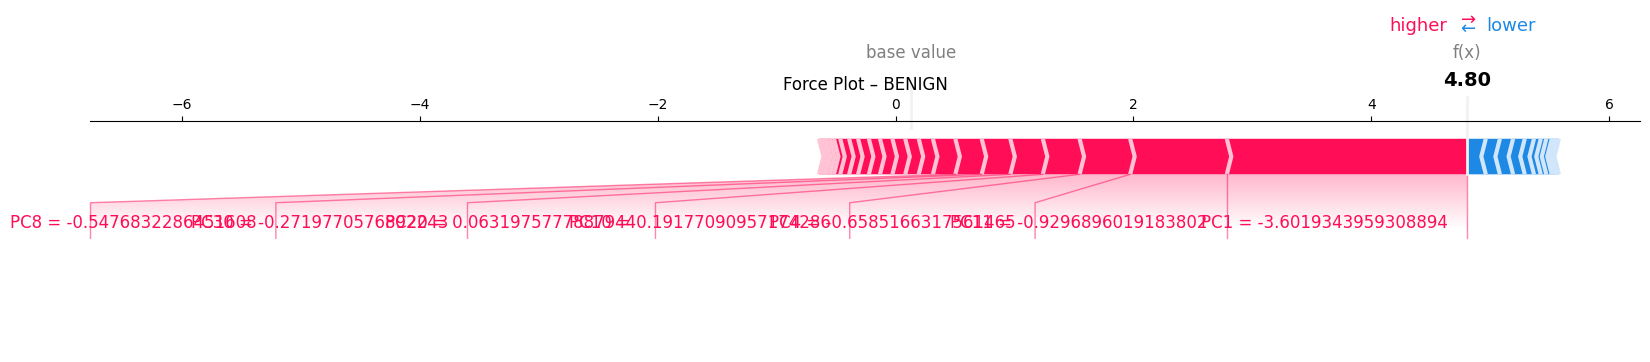


Prediction: BENIGN  (100.0%)
True label : BENIGN

Features that increased attack probability:
  •                          PC1 = -3.6  →  +2.019
  •                        PC11 = -0.93  →  +0.812
  •                        PC4 = -0.659  →  +0.425
  •                        PC10 = 0.192  →  +0.309
  •                       PC20 = 0.0632  →  +0.273

Features that decreased attack probability:
  •                       PC33 = 0.0594  →  -0.159
  •                        PC2 = -0.409  →  -0.118
  •                       PC19 = -0.437  →  -0.111
  •                        PC27 = 0.592  →  -0.098
  •                       PC13 = -0.548  →  -0.078


{'predicted_class': 'BENIGN',
 'confidence': 0.999842643737793,
 'true_label': 'BENIGN',
 'top_positive': [('PC1 = -3.6', '+2.019'),
  ('PC11 = -0.93', '+0.812'),
  ('PC4 = -0.659', '+0.425'),
  ('PC10 = 0.192', '+0.309'),
  ('PC20 = 0.0632', '+0.273'),
  ('PC30 = -0.272', '+0.241')],
 'top_negative': [('PC33 = 0.0594', '-0.159'),
  ('PC2 = -0.409', '-0.118'),
  ('PC19 = -0.437', '-0.111'),
  ('PC27 = 0.592', '-0.098'),
  ('PC13 = -0.548', '-0.078'),
  ('PC32 = -0.171', '-0.057')]}

In [51]:

model          = xgb
# X_train        = training features (pandas DataFrame)
# X_test         = test features
# y_train, y_test

class_names = get_class_names(y_train)   # or y  → should return ["BENIGN", "DDoS", "DoS"]
background = X_train.sample(200, random_state=42)

explainer = compute_global_shap(model, background)

# Global importance
shap_values_global = explainer(background)

plot_global_shap_summary(shap_values_global, background, class_names)
display(global_feature_importance_table(shap_values_global.values, X_train.columns, top_n=15))

# Explain one example
idx = 42
x_example = pd.DataFrame(X_test).iloc[[idx]]
true_y = y_test_enc[idx]

explain_single_prediction(
    model,
    explainer,
    x_example,
    class_names,
    true_label=true_y
)

In [52]:
import shap
import numpy as np
import matplotlib.pyplot as plt

class SHAPExplainer:
    def __init__(self, model, X_train, model_type="auto"):
        self.model = model
        self.X_train = X_train

        self.explainer = shap.TreeExplainer(model)

        self.shap_values = self.explainer(X_train)

    def summary_plot(self):
        shap.plots.beeswarm(self.shap_values)
        plt.show()

    def summary_bar(self):
        shap.plots.bar(self.shap_values)
        plt.show()

    def dependence_plot(self, feature_name):
        shap.plots.scatter(
            self.shap_values[:, feature_name],
            color=self.shap_values
        )
        plt.show()

    def interaction_heatmap(self):
        interaction_values = self.explainer.shap_interaction_values(self.X_train)

        if isinstance(interaction_values, list):
            interaction_values = interaction_values[0]

        shap.summary_plot(interaction_values, self.X_train)
        plt.show()

In [53]:
class LocalSHAPExplainer:
    def __init__(self, model, X_train):
        self.model = model
        self.explainer = shap.TreeExplainer(model)
        self.X_train = X_train

    def explain_instance(self, instance):
        shap_values = self.explainer(instance)

        shap.plots.force(shap_values[0], matplotlib=True)
        plt.show()

        shap.plots.waterfall(shap_values[0])
        plt.show()

        contributions = shap_values.values[0]

        contribution_df = (
            pd.DataFrame({
                "Feature": instance.columns,
                "Contribution": contributions
            })
            .sort_values("Contribution", key=abs, ascending=False)
        )

        return contribution_df

In [54]:
class InteractionExplainer:
    def __init__(self, model, X_train):
        self.model = model
        self.X_train = X_train
        self.explainer = shap.TreeExplainer(model)

    def interaction_values(self):
        interaction_values = self.explainer.shap_interaction_values(self.X_train)
        return interaction_values

    def interaction_summary(self):
        shap.summary_plot(
            self.explainer.shap_interaction_values(self.X_train),
            self.X_train
        )

In [55]:
!pip install dice-ml

import dice_ml
from dice_ml import Dice

class CounterfactualExplainer:
    def __init__(self, model, X_train, target_name):
        data = dice_ml.Data(
            dataframe=X_train,
            continuous_features=X_train.columns.tolist(),
            outcome_name=target_name
        )

        model_dice = dice_ml.Model(model=model, backend="sklearn")

        self.exp = Dice(data, model_dice)

    def generate(self, instance):
        cf = self.exp.generate_counterfactuals(
            instance,
            total_CFs=3,
            desired_class="opposite"
        )
        return cf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.2 MB/s eta 0:00:00


In [56]:
def group_shap_analysis(shap_values, X, sensitive_feature):
    df = pd.DataFrame(shap_values, columns=X.columns)
    df[sensitive_feature] = X[sensitive_feature].values

    group_means = df.groupby(sensitive_feature).mean()
    return group_means

In [57]:
class RealTimeExplainer:
    def __init__(self, model, X_train):
        self.model = model
        self.explainer = shap.TreeExplainer(model)
        self.X_train = X_train

    def explain_prediction(self, input_data):
        prediction = self.model.predict(input_data)[0]
        shap_values = self.explainer.shap_values(input_data)

        contribution_df = pd.DataFrame({
            "feature": input_data.columns,
            "contribution": shap_values[0]
        }).sort_values("contribution", key=abs, ascending=False)

        explanation = f"""
        Prediction: {prediction}

        Top contributing features:
        {contribution_df.head(5).to_string(index=False)}
        """

        return {
            "prediction": prediction,
            "shap_values": shap_values,
            "contributions": contribution_df,
            "explanation": explanation
        }

In [58]:
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

In [59]:
shap_vals_attack = shap_values[:, :, 1]   # Class 1 = DDoS

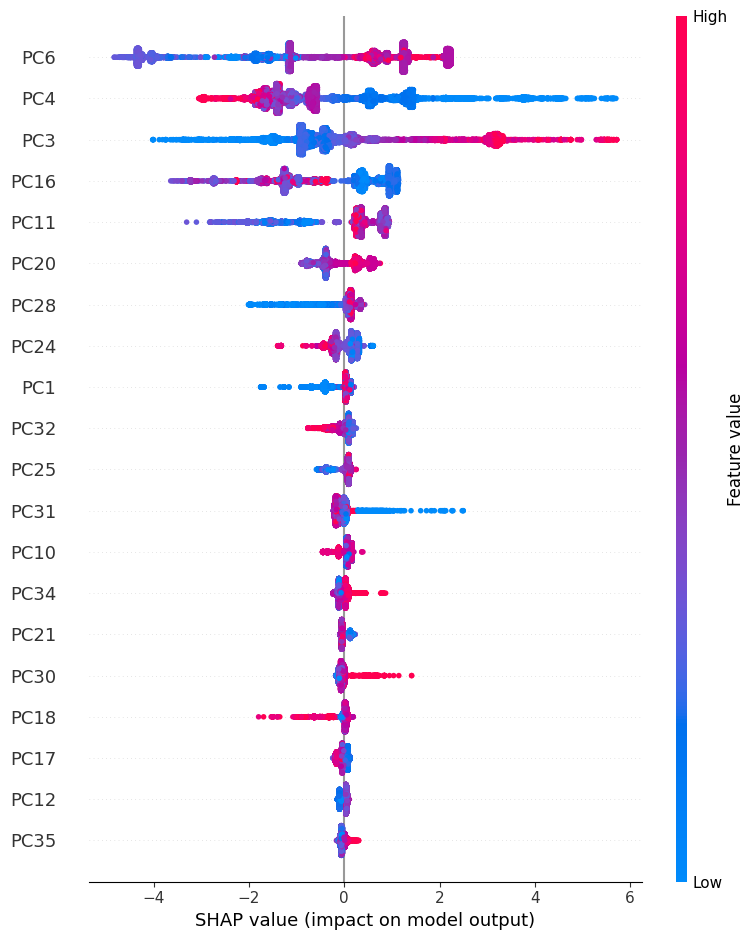

In [60]:
shap.summary_plot(shap_vals_attack, X_train)

In [61]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": np.abs(shap_vals_attack).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.head(15))

   feature  mean_abs_shap
5      PC6       1.764590
3      PC4       1.296473
2      PC3       1.176448
15    PC16       0.945124
10    PC11       0.685771
19    PC20       0.411889
27    PC28       0.198973
23    PC24       0.196947
0      PC1       0.163352
31    PC32       0.134378
24    PC25       0.122374
30    PC31       0.103043
9     PC10       0.089351
33    PC34       0.083439
20    PC21       0.067181


In [62]:
comparison = pd.DataFrame({
    "feature": X_train.columns,
    "model_importance": model.feature_importances_,
    "shap_importance": np.abs(shap_vals_attack).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

print(comparison.head(15))

   feature  model_importance  shap_importance
5      PC6          0.169473         1.764590
3      PC4          0.039388         1.296473
2      PC3          0.018623         1.176448
15    PC16          0.090852         0.945124
10    PC11          0.176711         0.685771
19    PC20          0.000878         0.411889
27    PC28          0.042868         0.198973
23    PC24          0.043714         0.196947
0      PC1          0.216301         0.163352
31    PC32          0.003311         0.134378
24    PC25          0.003404         0.122374
30    PC31          0.004091         0.103043
9     PC10          0.004603         0.089351
33    PC34          0.003323         0.083439
20    PC21          0.003845         0.067181


In [63]:
top_ratio = importance_df.iloc[0]["mean_abs_shap"] / importance_df["mean_abs_shap"].sum()

if top_ratio > 0.5:
    print("⚠️ Model overly depends on single network feature.")
else:
    print("Model decisions distributed across traffic features.")

Model decisions distributed across traffic features.


In [64]:
instance = X_test.iloc[[10]]

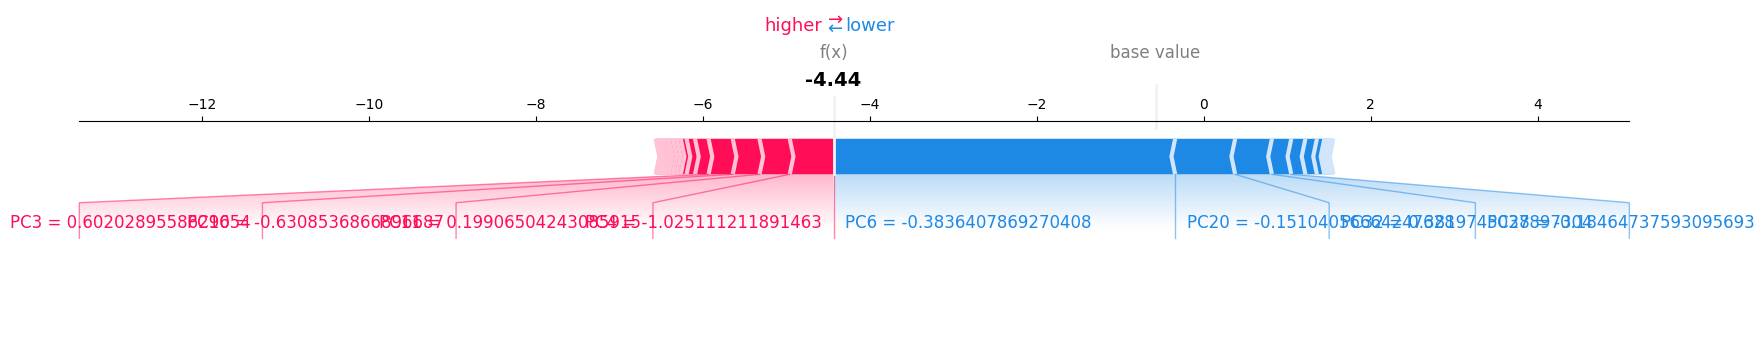

In [65]:
# Get the Explanation object for the single instance
shap_explanation_for_instance = explainer(instance)

# Extract the base value for class 1 (DDoS)
base_value_class1 = explainer.expected_value[1]

shap_values_class1 = shap_explanation_for_instance.values[0, :, 1]

shap.force_plot(
    base_value_class1,
    shap_values_class1,
    instance,
    matplotlib=True
)

In [66]:
# Assuming 'explainer' and 'instance' are defined from previous cells.

shap_explanation = explainer(instance) # Get the shap.Explanation object for the single instance

# Extract SHAP values for class 1 (DDoS) for this single instance
# shap_explanation.values is of shape (1, num_features, num_classes)
# We want values for the first sample (index 0), all features (all :), and class 1 (index 1)
local_shap = shap_explanation.values[0, :, 1]

contrib_df = pd.DataFrame({
    "feature": X_train.columns,
    "contribution": local_shap
}).sort_values("contribution", key=abs, ascending=False)

print(contrib_df.head(10))

   feature  contribution
5      PC6     -4.092160
19    PC20     -0.718573
3      PC4      0.524052
31    PC32     -0.440448
10    PC11      0.362501
15    PC16      0.320454
2      PC3      0.289618
27    PC28     -0.231777
16    PC17     -0.169318
20    PC21      0.162188


In [68]:
instance = X_test.iloc[[10]]

rules = xgb_decision_path(model, instance)

for r in rules:
    print(r)

PC1 >= -3.54573154
PC11 >= -0.789856076
PC24 >= -0.482744008
PC9 < 1.29673219
PC35 < 0.167993426
PC2 < 2.4071579


In [69]:
import dice_ml
from dice_ml import Dice

df_train = X_train.copy()
df_train["Label"] = y_train

data_dice = dice_ml.Data(
    dataframe=df_train,
    continuous_features=X_train.columns.tolist(),
    outcome_name="Label"
)

model_dice = dice_ml.Model(model=model, backend="sklearn")
dice_exp = Dice(data_dice, model_dice)

In [70]:
cf = dice_exp.generate_counterfactuals(
    instance,
    total_CFs=3,
    desired_class=0 # Changed from "opposite" to a specific class label (0 for BENIGN)
)

cf.visualize_as_dataframe()

100%|██████████| 1/1 [00:03<00:00,  3.89s/it]

Query instance (original outcome : 2)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Label
0,4.200158,-0.625488,0.602029,-1.025111,2.056774,-0.383641,-0.115251,-0.352465,0.454775,-0.057204,...,-0.185215,-0.184647,0.122441,-0.418991,0.306248,0.381975,0.014673,-0.268214,0.107838,2



Diverse Counterfactual set (new outcome: 0)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Label
0,4.200158,28.841375,0.602029,-1.025111,2.056774,-0.383641,-0.115251,-0.352465,0.454775,-0.057204,...,-0.185215,8.331573,0.122441,-0.418991,0.306248,0.381975,0.014673,-0.268214,0.107838,0
1,4.200158,163.835864,0.602029,-1.025111,2.056774,-0.383641,-0.115251,-0.352465,0.454775,-0.057204,...,-0.185215,-0.184647,0.122441,-0.418991,0.306248,0.381975,0.014673,-0.268214,0.107838,0
2,4.200158,155.817899,0.602029,-1.025111,2.056774,-0.383641,-0.115251,-0.352465,0.454775,-0.057204,...,-0.185215,-0.184647,0.122441,-0.418991,0.306248,0.381975,0.014673,-0.268214,0.107838,0


In [71]:
def explain_prediction(input_data):
    prediction = model.predict(input_data)[0]
    shap_explanation = explainer(input_data)
    shap_vals = shap_explanation.values[0, :, 1]

    contrib_df = pd.DataFrame({
        "feature": X_train.columns,
        "contribution": shap_vals
    }).sort_values("contribution", key=abs, ascending=False)

    explanation = f"""
    Prediction: {'ATTACK' if prediction == 1 else 'BENIGN'}

    Top driving network features:
    {contrib_df.head(5).to_string(index=False)}
    """

    return {
        "prediction": prediction,
        "contributions": contrib_df,
        "explanation": explanation
    }

In [72]:
result = explain_prediction(instance)
print(result["explanation"])


    Prediction: BENIGN

    Top driving network features:
    feature  contribution
    PC6     -4.092160
   PC20     -0.718573
    PC4      0.524052
   PC32     -0.440448
   PC11      0.362501
    


In [73]:
import pickle

# Open a file in binary write mode ('wb')
with open('random_forest_model.pkl', 'wb') as file:
    # Use pickle.dump() to save the rf model to the opened file
    pickle.dump(rf, file)

print("RandomForestClassifier model has been saved as 'random_forest_model.pkl'")

RandomForestClassifier model has been saved as 'random_forest_model.pkl'


In [74]:
import pickle

# Open a file in binary write mode ('wb')
with open('logistic_regression_model.pkl', 'wb') as file:
    # Use pickle.dump() to save the lr1 model to the opened file
    pickle.dump(lr1, file)

print("LogisticRegression model has been saved as 'logistic_regression_model.pkl'")

LogisticRegression model has been saved as 'logistic_regression_model.pkl'


In [75]:
import pickle

# Open a file in binary write mode ('wb')
with open('decision_tree_model.pkl', 'wb') as file:
    # Use pickle.dump() to save the dt model to the opened file
    pickle.dump(dt, file)

print("DecisionTreeClassifier model has been saved as 'decision_tree_model.pkl'")

DecisionTreeClassifier model has been saved as 'decision_tree_model.pkl'


In [77]:
cnn_model.save('cnn_model.h5')
print("CNN model saved as 'cnn_model.h5'")

CNN model saved as 'cnn_model.h5'


In [78]:
cnn_model.save('cnn_model.h5')
print("CNN model saved as 'cnn_model.h5'")

CNN model saved as 'cnn_model.h5'


In [79]:
cnn_model.save('cnn_model.h5')
print("CNN model saved as 'cnn_model.h5'")

CNN model saved as 'cnn_model.h5'


In [80]:
import os

# 1. Define model directory
MODEL_DIR = 'models'

# 2. Create the directory if it does not already exist
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Model directory '{MODEL_DIR}' ensured to exist.")

# 3. Define scaler filename
SCALER_FILENAME = 'scaler.pkl'

# 4. Define PCA filename
PCA_FILENAME = 'ipca.pkl'

# 5. Define SHAP explainer filename
SHAP_EXPLAINER_FILENAME = 'shap_explainer.pkl'

# 6. Construct the full file path for the scaler
SCALER_PATH = os.path.join(MODEL_DIR, SCALER_FILENAME)
print(f"Scaler path: {SCALER_PATH}")

# 7. Construct the full file path for the IncrementalPCA object
PCA_PATH = os.path.join(MODEL_DIR, PCA_FILENAME)
print(f"PCA path: {PCA_PATH}")

# 8. Construct the full file path for the SHAP explainer object
SHAP_EXPLAINER_PATH = os.path.join(MODEL_DIR, SHAP_EXPLAINER_FILENAME)
print(f"SHAP Explainer path: {SHAP_EXPLAINER_PATH}")

Model directory 'models' ensured to exist.
Scaler path: models/scaler.pkl
PCA path: models/ipca.pkl
SHAP Explainer path: models/shap_explainer.pkl
